In [14]:
import pandas as pd
import numpy as np
from scipy import sparse
import json
from binn import BINN, BINNDataLoader, BINNTrainer , BINNExplainer

# =============================================================================
# Data Loading
# =============================================================================

In [15]:
def load_genotype_data(file_path='dummy_genotype_matrix.npz'):
    loaded = np.load(file_path, allow_pickle=True)
    return loaded['matrix'], loaded['snps'], loaded['samples']

def load_gene_index(file_path='gene_index.json'):
    with open(file_path, 'r') as f:
        gene_index = json.load(f)
    return list(gene_index.keys())

def load_snp_gene_sparse_matrix(file_path='sparse_matrix.npz'):
    sparse_loaded = np.load(file_path, allow_pickle=True)
    if 'data' in sparse_loaded.keys():
        return sparse.csr_matrix(
            (sparse_loaded['data'], sparse_loaded['indices'], sparse_loaded['indptr']),
            shape=tuple(sparse_loaded['shape'])
        )
    return sparse_loaded['matrix']

# Load data
genotype_matrix, snps, samples = load_genotype_data()
gene_names = load_gene_index()
snp_to_gene_sparse = load_snp_gene_sparse_matrix()
print(f"Data loaded: {genotype_matrix.shape[0]} patients, {genotype_matrix.shape[1]} SNPs, {len(gene_names)} genes")

Data loaded: 50 patients, 100 SNPs, 122 genes


# =============================================================================
# Prepare SNP Data
# =============================================================================

In [16]:
def prepare_snp_data_for_binn(genotype_matrix, snps):
    sample_names = [f"Patient_{i}" for i in range(genotype_matrix.shape[0])]
    snp_data = pd.DataFrame(
        genotype_matrix.T,
        index=snps,
        columns=sample_names
    ).reset_index().rename(columns={'index': 'SNP'})
    return snp_data, sample_names

snp_data, sample_names = prepare_snp_data_for_binn(genotype_matrix, snps)
print(f"SNP data prepared: {snp_data.shape}")

SNP data prepared: (100, 51)


# =============================================================================
# Generate Clinical Data
# =============================================================================

In [17]:
def generate_clinical_data(sample_names):
    n_patients = len(sample_names)
    np.random.seed(42)
    
    ages = np.clip(np.random.normal(65, 15, n_patients).astype(int), 30, 90)
    genders = np.random.choice(['Male', 'Female'], n_patients, p=[0.6, 0.4])
    disease_status = np.random.choice(['MI', 'Atherosclerosis', 'Control'], n_patients, p=[0.15, 0.15, 0.7])
    
    base_cholesterol = np.random.normal(200, 40, n_patients)
    disease_effect = np.where(disease_status != 'Control', 
                             np.random.normal(50, 20, n_patients), 
                             np.random.normal(0, 10, n_patients))
    total_cholesterol = np.clip(base_cholesterol + disease_effect, 120, 400)
    
    base_bp = np.random.normal(130, 20, n_patients)
    bp_effect = np.where(disease_status != 'Control', 
                        np.random.normal(20, 10, n_patients), 
                        np.random.normal(0, 5, n_patients))
    systolic_bp = np.clip(base_bp + bp_effect, 90, 200)
    
    base_bmi = np.random.normal(27, 5, n_patients)
    bmi_effect = np.where(disease_status != 'Control', 3, 0)
    bmi = np.clip(base_bmi + bmi_effect, 18, 45)
    
    smoking_prob = np.where(disease_status != 'Control', 0.7, 0.3)
    smoking_history = np.random.binomial(1, smoking_prob, n_patients)
    
    diabetes_prob = np.where(disease_status != 'Control', 0.4, 0.1)
    diabetes = np.random.binomial(1, diabetes_prob, n_patients)
    
    return pd.DataFrame({
        'patient_id': sample_names,
        'age': ages,
        'gender': genders,
        'disease_status': disease_status,
        'total_cholesterol': np.round(total_cholesterol, 1),
        'systolic_bp': systolic_bp.astype(int),
        'bmi': np.round(bmi, 1),
        'smoking_history': smoking_history.astype(bool),
        'diabetes': diabetes.astype(bool)
    })

clinical_data = generate_clinical_data(sample_names)
print(f"Clinical data generated: {clinical_data.shape}")


Clinical data generated: (50, 9)


# =============================================================================
# Process Clinical Features
# =============================================================================

In [18]:
def prepare_clinical_features(clinical_data):
    clinical_features = clinical_data.copy()
    
    clinical_features['gender_encoded'] = clinical_features['gender'].map({'Male': 1, 'Female': 0})
    clinical_features['smoking_encoded'] = clinical_features['smoking_history'].astype(int)
    clinical_features['diabetes_encoded'] = clinical_features['diabetes'].astype(int)
    
    continuous_vars = ['age', 'total_cholesterol', 'systolic_bp', 'bmi']
    for var in continuous_vars:
        min_val = clinical_features[var].min()
        max_val = clinical_features[var].max()
        clinical_features[f'{var}_normalized'] = (clinical_features[var] - min_val) / (max_val - min_val)
    
    feature_columns = [
        'age_normalized', 'total_cholesterol_normalized', 'systolic_bp_normalized', 
        'bmi_normalized', 'gender_encoded', 'smoking_encoded', 'diabetes_encoded'
    ]
    
    return clinical_features[feature_columns].values, feature_columns

clinical_matrix, clinical_feature_names = prepare_clinical_features(clinical_data)
print(f"Clinical features: {clinical_feature_names}")


Clinical features: ['age_normalized', 'total_cholesterol_normalized', 'systolic_bp_normalized', 'bmi_normalized', 'gender_encoded', 'smoking_encoded', 'diabetes_encoded']


# =============================================================================
# Create Combined Data
# =============================================================================

In [19]:
def create_combined_snp_clinical_data(snp_data, clinical_matrix, clinical_feature_names, sample_names):
    snp_matrix = snp_data.drop('SNP', axis=1).values
    clinical_matrix_T = clinical_matrix.T
    combined_matrix = np.vstack([snp_matrix, clinical_matrix_T])
    
    snp_names = snp_data['SNP'].tolist()
    all_feature_names = snp_names + clinical_feature_names
    
    combined_data = pd.DataFrame(
        combined_matrix,
        index=all_feature_names,
        columns=sample_names
    ).reset_index().rename(columns={'index': 'SNP'})
    
    return combined_data, snp_names

combined_data, snp_names = create_combined_snp_clinical_data(
    snp_data, clinical_matrix, clinical_feature_names, sample_names
)
print(f"Combined data: {combined_data.shape}")


Combined data: (107, 51)


# =============================================================================
# Create SNP-Gene Mapping
# =============================================================================

In [20]:
def create_snp_gene_mapping(snps, gene_names, snp_to_gene_sparse):
    coo_matrix = snp_to_gene_sparse.tocoo()
    snp_gene_mappings = []
    
    for snp_idx, gene_idx in zip(coo_matrix.row, coo_matrix.col):
        if snp_idx < len(snps) and gene_idx < len(gene_names):
            snp_gene_mappings.append({
                'input': snps[snp_idx],
                'translation': gene_names[gene_idx]
            })
    
    return pd.DataFrame(snp_gene_mappings)

snp_gene_mapping_df = create_snp_gene_mapping(snps, gene_names, snp_to_gene_sparse)
print(f"SNP-gene mappings: {len(snp_gene_mapping_df)}")

SNP-gene mappings: 130


# =============================================================================
# Create Dense Clinical → Dummy Pathways
# =============================================================================

In [21]:
def create_clinical_dummy_mapping(clinical_feature_names):
    """Each clinical feature connects to ALL dummy pathways."""
    print("Creating clinical → dummy pathway mapping...")
    
    # Create unique dummy pathways for each clinical feature
    dummy_pathways = [f"CLINICAL_{feat.upper()}_PATHWAY" for feat in clinical_feature_names]
    
    # Each clinical feature connects to ALL dummy pathways
    mappings = []
    for clinical_feature in clinical_feature_names:
        for dummy_pathway in dummy_pathways:
            mappings.append({
                'input': clinical_feature,
                'translation': dummy_pathway
            })
    
    clinical_dummy_df = pd.DataFrame(mappings)
    print(f"Created {len(clinical_dummy_df)} clinical→dummy mappings")
    print(f"Each of {len(clinical_feature_names)} clinical features → {len(dummy_pathways)} dummy pathways")
    
    return clinical_dummy_df, dummy_pathways

clinical_dummy_df, dummy_pathways = create_clinical_dummy_mapping(clinical_feature_names)


Creating clinical → dummy pathway mapping...
Created 49 clinical→dummy mappings
Each of 7 clinical features → 7 dummy pathways


# =============================================================================
# Create Dense Dummy → Real Pathways (One-to-Many)
# =============================================================================

In [23]:
# Define real pathways for SNP-gene mappings only
real_pathways = [
    'R-HSA-2559583',  # Cellular senescence (aging)
    'R-HSA-8957322',  # Metabolism of steroids (cholesterol/hormones)
    'R-HSA-2644602',  # Fatty acid metabolism (lipids/BMI)
    'R-HSA-5619115',  # Disorders of transmembrane transporters (BP/general)
    'R-HSA-418594',   # G alpha (s) signalling events (cardiovascular)
    'R-HSA-372790',   # Signaling by GPCR (blood pressure)
    'R-HSA-1640170',  # Cell Cycle (aging/growth)
    'R-HSA-162582',   # Signal Transduction (general signaling)
    'R-HSA-392499',   # Metabolism of proteins (general metabolism)
    'R-HSA-1430728'   # Metabolism (general metabolic processes)
]

def create_dummy_hierarchy(dummy_pathways):
    """Create hierarchy for dummy pathways only (no connection to real pathways)."""
    print("Creating dummy pathway hierarchy...")
    
    dummy_hierarchy_entries = []
    
    # Add each dummy pathway to clinical root
    for dummy_pathway in dummy_pathways:
        dummy_hierarchy_entries.append({
            'source': dummy_pathway,
            'target': 'CLINICAL_ROOT_PATHWAY'
        })
    
    # Add clinical root as top level
    dummy_hierarchy_entries.append({
        'source': 'CLINICAL_ROOT_PATHWAY',
        'target': 'CLINICAL_TOP_LEVEL'
    })
    
    dummy_hierarchy_df = pd.DataFrame(dummy_hierarchy_entries)
    print(f"Created {len(dummy_hierarchy_df)} dummy hierarchy entries")
    return dummy_hierarchy_df

def create_gene_pathway_mapping(gmt_file='ReactomePathways.gmt'):
    gene_to_pathway = []
    
    try:
        with open(gmt_file, 'r') as f:
            for line in f:
                parts = line.strip().split('\t')
                if len(parts) >= 3:
                    reactome_id = parts[1]
                    genes = parts[2:]
                    for gene in genes:
                        gene_to_pathway.append({
                            'input': gene,
                            'translation': reactome_id
                        })
    except FileNotFoundError:
        print("GMT file not found. Creating dummy gene-pathway mappings with real R-HSA IDs.")
        for i, gene in enumerate(gene_names):
            if i < len(real_pathways) * 10:
                gene_to_pathway.append({
                    'input': gene,
                    'translation': real_pathways[i % len(real_pathways)]
                })
    
    return pd.DataFrame(gene_to_pathway)

def load_pathway_hierarchy(file_path='reactome_pathways_relation_2025_01_14.txt'):
    try:
        pathways_df = pd.read_csv(file_path, sep='\t', header=None)
        pathways_df.columns = ['source', 'target']
        print(f"Loaded {len(pathways_df)} pathway hierarchy connections")
    except FileNotFoundError:
        print("Hierarchy file not found. Creating dummy hierarchy with real R-HSA IDs.")
        pathways_df = pd.DataFrame({
            'source': real_pathways * 50,
            'target': ['R-HSA-SUPER_1', 'R-HSA-SUPER_2', 'R-HSA-SUPER_3'] * (len(real_pathways) * 50 // 3 + 1)
        }).head(len(real_pathways) * 50)
    
    return pathways_df

gene_pathway_mapping_df = create_gene_pathway_mapping()
pathways_hierarchy_df = load_pathway_hierarchy()
# Create separate hierarchies - no connection between dummy and real pathways
dummy_hierarchy_df = create_dummy_hierarchy(dummy_pathways)
print(f"Gene-pathway mappings: {len(gene_pathway_mapping_df)}")
print(f"SNP pathway hierarchy: {len(pathways_hierarchy_df)}")
print(f"Clinical dummy hierarchy: {len(dummy_hierarchy_df)}")

Loaded 22746 pathway hierarchy connections
Creating dummy pathway hierarchy...
Created 8 dummy hierarchy entries
Gene-pathway mappings: 135371
SNP pathway hierarchy: 22746
Clinical dummy hierarchy: 8


# =============================================================================
# Combine All Mappings
# =============================================================================

In [24]:
def combine_all_mappings(snp_gene_mapping_df, clinical_dummy_df):
    """Combine SNP-gene and clinical-dummy mappings."""
    print("Combining all mappings...")
    
    combined_mapping = pd.concat([snp_gene_mapping_df, clinical_dummy_df], ignore_index=True)
    
    print(f"Total mappings: {len(combined_mapping)}")
    print(f"- SNP→gene: {len(snp_gene_mapping_df)}")
    print(f"- Clinical→dummy: {len(clinical_dummy_df)}")
    
    return combined_mapping

combined_mapping_df = combine_all_mappings(snp_gene_mapping_df, clinical_dummy_df)


Combining all mappings...
Total mappings: 179
- SNP→gene: 130
- Clinical→dummy: 49


# =============================================================================
# Create Pathways
# =============================================================================

In [25]:
def create_pathways_system(gene_pathway_mapping_df, dummy_hierarchy_df, pathways_hierarchy_df):
    """Create two separate pathway systems - SNP→gene→real pathways and clinical→dummy pathways."""
    print("Creating separate pathway systems...")
    
    # Convert gene-pathway mappings to source-target format
    gene_pathway_edges = []
    for _, row in gene_pathway_mapping_df.iterrows():
        gene_pathway_edges.append({
            'source': row['input'],
            'target': row['translation']
        })
    gene_pathway_df = pd.DataFrame(gene_pathway_edges)
    
    # Combine SNP system: Gene→Real pathway + Real pathway hierarchy
    snp_pathways_df = pd.concat([
        gene_pathway_df,        # Gene → Real Pathway
        pathways_hierarchy_df   # Real pathway hierarchy
    ], ignore_index=True)
    
    # Clinical system is just the dummy hierarchy
    clinical_pathways_df = dummy_hierarchy_df.copy()
    
    # For BINN, we need to combine both systems
    all_pathways_df = pd.concat([
        snp_pathways_df,
        clinical_pathways_df
    ], ignore_index=True)
    
    print(f"SNP pathways: {len(snp_pathways_df)} connections")
    print(f"Clinical pathways: {len(clinical_pathways_df)} connections") 
    print(f"Combined pathways: {len(all_pathways_df)} connections")
    
    return all_pathways_df

all_pathways_df = create_separate_pathways_system(gene_pathway_mapping_df, dummy_hierarchy_df, pathways_hierarchy_df)

Creating separate pathway systems...
SNP pathways: 158117 connections
Clinical pathways: 8 connections
Combined pathways: 158125 connections


# =============================================================================
# Create Design Matrix
# =============================================================================

In [26]:
def create_design_matrix(clinical_data):
    return pd.DataFrame({
        'sample': clinical_data['patient_id'],
        'group': clinical_data['disease_status']
    })

design_matrix = create_design_matrix(clinical_data)
print(f"Design matrix: {design_matrix.shape}")

Design matrix: (50, 2)


# =============================================================================
# Create BINN Model
# =============================================================================



In [27]:
def create_binn(combined_data, combined_mapping_df, all_pathways_df):
    """Create BINN with separate SNP and clinical pathway systems."""
    print("Creating BINN with separate pathway systems...")
    
    print(f"Input verification:")
    print(f"  Combined data: {combined_data.shape}")
    print(f"  Combined mappings: {len(combined_mapping_df)}")
    print(f"  All pathways: {len(all_pathways_df)}")
    
    binn = BINN(
        data_matrix=combined_data,
        mapping=combined_mapping_df,
        pathways=all_pathways_df,
        entity_col='SNP',
        input_col='input',
        translation_col='translation',
        source_col='source',
        target_col='target',
        n_layers=4,
        n_outputs=3,
        dropout=0.2,
        device='cpu'
    )
    
    print(f"BINN created: {len(binn.inputs)} input features")
    return binn

binn = create_binn(combined_data, combined_mapping_df, all_pathways_df)

Creating BINN with separate pathway systems...
Input verification:
  Combined data: (107, 51)
  Combined mappings: 179
  All pathways: 158125

[INFO] BINN is on device: cpu
BINN created: 56 input features


# =============================================================================
# Verify Integration
# =============================================================================


In [29]:
def verify_separate_integration(binn, clinical_feature_names, dummy_pathways):
    """Verify clinical features and dummy pathways are in the network as separate systems."""
    print("="*60)
    print("VERIFICATION")
    print("="*60)
    
    # Check clinical features
    clinical_in_inputs = [feat for feat in clinical_feature_names if feat in binn.inputs]
    print(f"Clinical features in BINN: {len(clinical_in_inputs)}/{len(clinical_feature_names)}")
    
    # Check dummy pathways (should be in network layers, not connected to real pathways)
    dummy_in_layers = []
    for layer_names in binn.layer_names:
        dummies = [name for name in layer_names if name.startswith('CLINICAL_')]
        dummy_in_layers.extend(dummies)
    
    print(f"Dummy pathways in network: {len(dummy_in_layers)}")
    print(f"Total input features: {len(binn.inputs)}")
    
    success = len(clinical_in_inputs) == len(clinical_feature_names) and len(dummy_in_layers) > 0
    print(f"Status: {'SUCCESS' if success else 'FAILED'}")
    print("Architecture: SNPs→Genes→Real Pathways | Clinical→Dummy Pathways (separate)")
    
    if success:
        print(f"Clinical features: {clinical_in_inputs}")
        print(f"Dummy pathways: {dummy_in_layers}")
    
    return success

success = verify_separate_integration(binn, clinical_feature_names, dummy_pathways)


VERIFICATION
Clinical features in BINN: 7/7
Dummy pathways in network: 16
Total input features: 56
Status: SUCCESS
Architecture: SNPs→Genes→Real Pathways | Clinical→Dummy Pathways (separate)
Clinical features: ['age_normalized', 'total_cholesterol_normalized', 'systolic_bp_normalized', 'bmi_normalized', 'gender_encoded', 'smoking_encoded', 'diabetes_encoded']
Dummy pathways: ['CLINICAL_AGE_NORMALIZED_PATHWAY', 'CLINICAL_BMI_NORMALIZED_PATHWAY', 'CLINICAL_DIABETES_ENCODED_PATHWAY', 'CLINICAL_GENDER_ENCODED_PATHWAY', 'CLINICAL_SMOKING_ENCODED_PATHWAY', 'CLINICAL_SYSTOLIC_BP_NORMALIZED_PATHWAY', 'CLINICAL_TOTAL_CHOLESTEROL_NORMALIZED_PATHWAY', 'CLINICAL_AGE_NORMALIZED_PATHWAY', 'CLINICAL_BMI_NORMALIZED_PATHWAY', 'CLINICAL_DIABETES_ENCODED_PATHWAY', 'CLINICAL_GENDER_ENCODED_PATHWAY', 'CLINICAL_SMOKING_ENCODED_PATHWAY', 'CLINICAL_SYSTOLIC_BP_NORMALIZED_PATHWAY', 'CLINICAL_TOTAL_CHOLESTEROL_NORMALIZED_PATHWAY', 'CLINICAL_ROOT_PATHWAY', 'CLINICAL_TOP_LEVEL']


# =============================================================================
# Train Model
# =============================================================================

In [30]:
if success:
    print("\n" + "="*60)
    print("TRAINING SEPARATE PATHWAY SYSTEMS MODEL")
    print("="*60)
    
    dataloader = BINNDataLoader(binn)
    dataloaders = dataloader.create_dataloaders(
        data_matrix=combined_data,
        design_matrix=design_matrix,
        feature_column="SNP",
        group_column="group",
        sample_column="sample",
        batch_size=8,
        validation_split=0.2
    )
    
    trainer = BINNTrainer(binn)
    trainer.fit(dataloaders=dataloaders, num_epochs=5)
    
    print("Training completed!")
else:
    print("Training skipped due to failed integration.")


TRAINING SEPARATE PATHWAY SYSTEMS MODEL
Mapping group labels: {'Atherosclerosis': 0, 'Control': 1, 'MI': 2}
[Epoch 1/5] Train Loss: 1.2377, Train Accuracy: 0.2500
[Epoch 1/5] Val Loss: 1.0907, Val Accuracy: 0.6250
[Epoch 2/5] Train Loss: 1.1342, Train Accuracy: 0.4000
[Epoch 2/5] Val Loss: 1.0828, Val Accuracy: 0.6250
[Epoch 3/5] Train Loss: 1.1606, Train Accuracy: 0.2500
[Epoch 3/5] Val Loss: 1.0760, Val Accuracy: 0.6250
[Epoch 4/5] Train Loss: 1.1033, Train Accuracy: 0.4250
[Epoch 4/5] Val Loss: 1.0683, Val Accuracy: 0.6250
[Epoch 5/5] Train Loss: 1.1828, Train Accuracy: 0.3500
[Epoch 5/5] Val Loss: 1.0597, Val Accuracy: 0.6250
Training completed!


In [116]:
# @markdown ### Explainer options

single_or_average = "single"  # @param ["single", "average"]
normalization_method = "fan"  # @param ["subgraph", "fan"]

# @markdown ---

# @markdown ### Options for average explainer
n_iterations = 3  # @param {type:"integer"}
num_epochs_explain = 50 # @param {type:"integer"}

from binn import BINNExplainer

explainer = BINNExplainer(binn)

if single_or_average == "average":
  explanations = explainer.explain(
      dataloaders,
      nr_iterations=n_iterations,
      trainer=trainer,
      num_epochs=num_epochs_explain,
      normalization_method=normalization_method
  )
else:
  explanations = explainer.explain_single(dataloaders, split=None, normalization_method=normalization_method)
explanations.to_csv('explnation.csv')
explanations

     

,source_layer,target_layer,source_node,target_node,class_idx,importance,normalized_importance
0,0,1,age_normalized,CLINICAL_AGE_NORMALIZED_PATHWAY,0,0.000484,0.000161
1,0,1,age_normalized,CLINICAL_AGE_NORMALIZED_PATHWAY,1,0.000050,0.000017
2,0,1,age_normalized,CLINICAL_AGE_NORMALIZED_PATHWAY,2,0.000251,0.000084
3,0,1,age_normalized,CLINICAL_BMI_NORMALIZED_PATHWAY,0,0.000484,0.000161
4,0,1,age_normalized,CLINICAL_BMI_NORMALIZED_PATHWAY,1,0.000050,0.000017
...,...,...,...,...,...,...,...
13669,4,5,R-HSA-997272,output_node,1,0.000003,0.000002
13670,4,5,R-HSA-997272,output_node,2,0.000007,0.000005
13671,4,5,ROOT_PATHWAY,output_node,0,0.000058,0.000036
13672,4,5,ROOT_PATHWAY,output_node,1,0.000018,0.000011


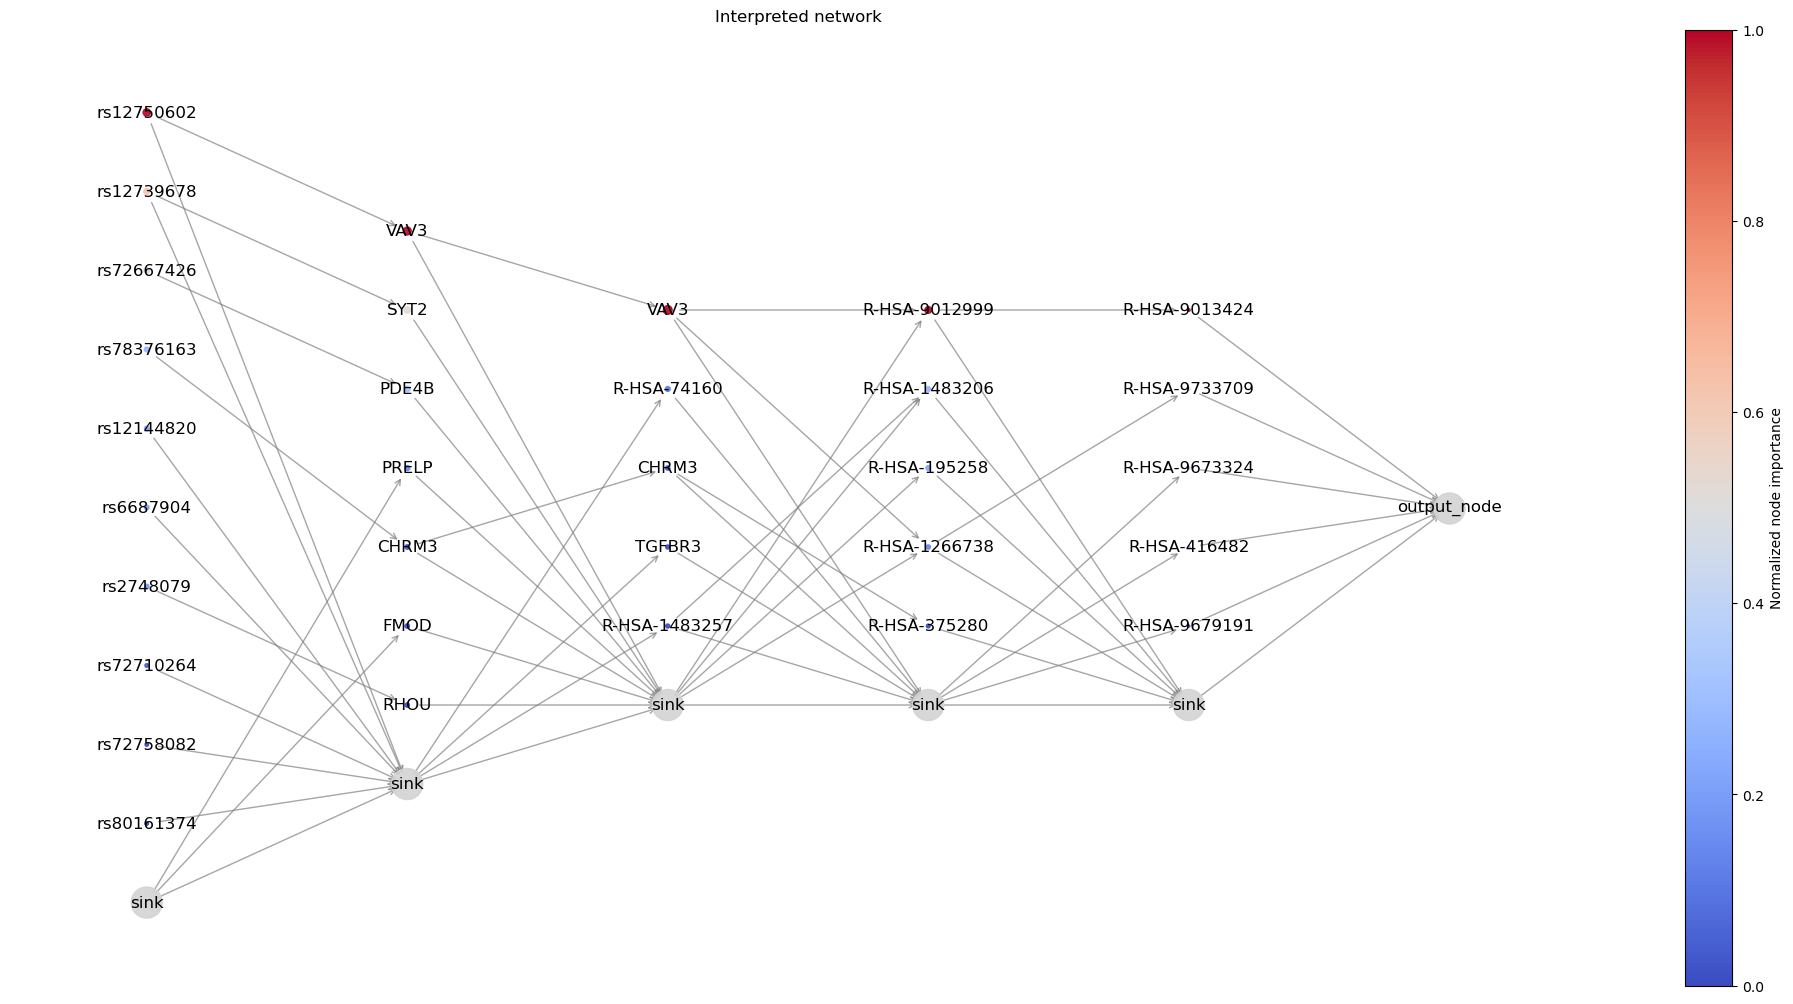

In [33]:
# @title ## 5. Plot
from binn.plot.network import visualize_binn

layer_specific_top_n = {"0": 10, "1": 7, "2": 5, "3": 5, "4": 5}

plt = visualize_binn(
    explanations,
    top_n=layer_specific_top_n,
    plot_size=(20, 10),
    sink_node_size=500,
    node_size_scaling=200,
    edge_width=1,
    node_cmap="coolwarm"
)

plt.title("Interpreted network")
plt.show()
     

/opt/anaconda3/lib/python3.12/site-packages/binn/plot/network.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe["source_layer"] = dataframe["source_layer"].astype(str)
/opt/anaconda3/lib/python3.12/site-packages/binn/plot/network.py:136: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataframe["target_layer"] = dataframe["target_layer"].astype(str)
/opt/anaconda3/lib/python3.12/site-packages/binn/plot/network.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

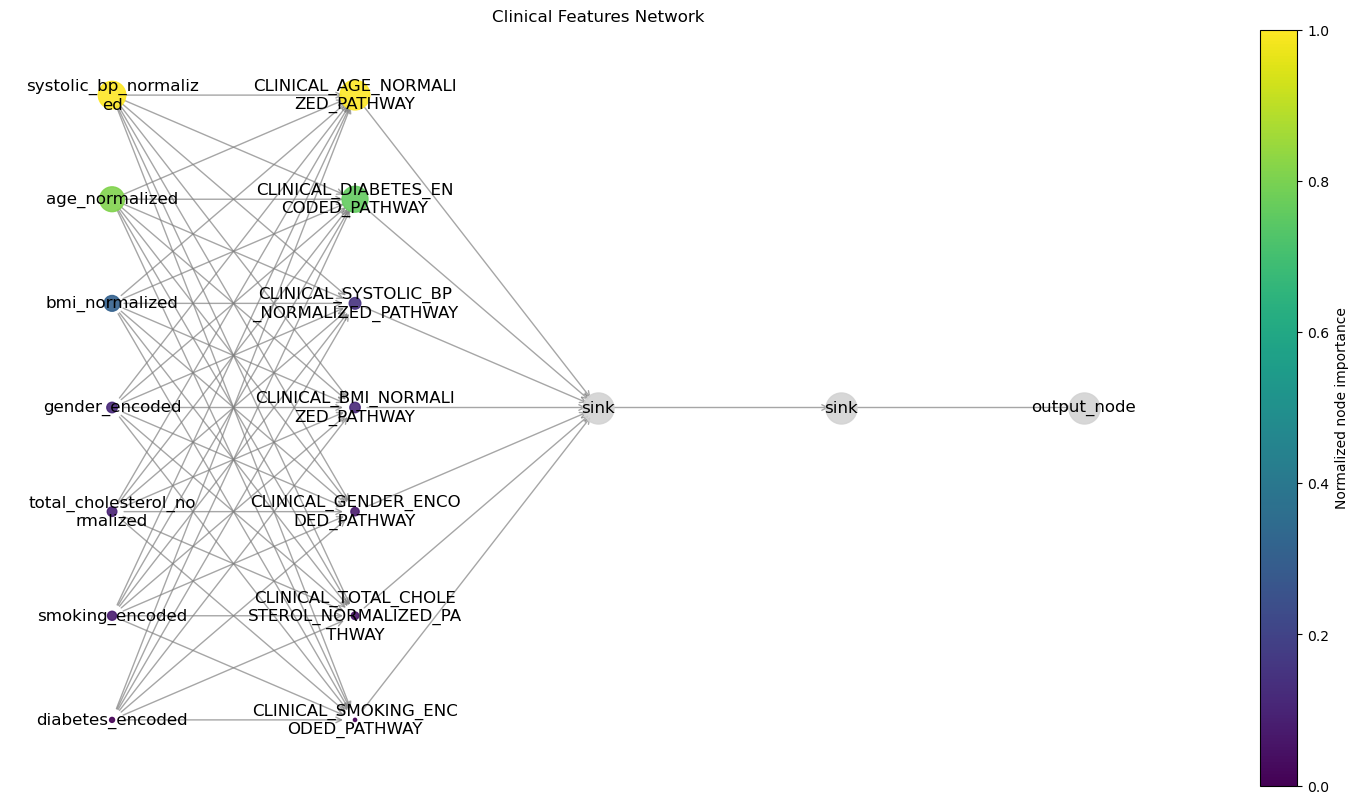

In [34]:
clinical_explanations = explanations[
    (explanations['source_node'].str.contains('_normalized|_encoded')) |
    (explanations['target_node'].str.contains('CLINICAL_'))
]

plt = visualize_binn(
    clinical_explanations,
    top_n={"0": 10, "1": 10},
    plot_size=(15, 8),
    node_size_scaling=1000,  # Much higher scaling for small values
    node_cmap="viridis"
)
plt.title("Clinical Features Network")
plt.show()